# A1 LFP Demo

Load one saved NetPyNE result, extract LFP as xarray, and inspect LFP, PSD, and CPSD over a shared time interval.

In [1]:
T_LIMITS = (5, 15)

LFP_TRACE_CHAN_IDX = 0
PSD_CHAN_IDX = 0
TF_CHAN_IDX = 0
CPSD_CHAN_IDXS = (0, 1)
WIN_LEN = 1.0
WIN_OVERLAP = 0.5
FMAX = 100.0

In [2]:
from pathlib import Path
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

DIR_PACKAGE = Path.cwd().parent
DIR_REPO = DIR_PACKAGE.parent
if str(DIR_REPO) not in sys.path:
    sys.path.insert(0, str(DIR_REPO))

from sim_data_analyzer.xr_adapters import get_lfp_xr
from sim_data_analyzer.xr_spect import calc_xr_cpsd, calc_xr_tf, calc_xr_welch

In [4]:
# Load simulation result from pkl
FPATH_SIM_RESULT = (
    DIR_PACKAGE / 'dev_scratch' / 'data_src' / 
    'a1_lfp_15s' / 'data_00000_seed_1000.pkl'
)
with FPATH_SIM_RESULT.open('rb') as fid:
    sim_result = pickle.load(fid)

print(FPATH_SIM_RESULT)
print('Duration (ms):', sim_result['simConfig']['duration'])
print('Record step (ms):', sim_result['simConfig']['recordStep'])
print('LFP samples x channels:', len(sim_result['simData']['LFP']), 'x', len(sim_result['simData']['LFP'][0]))

Tried loading an MPI library from:
libmpi.so: libmpi.so: cannot open shared object file: No such file or directory
libmpich.so: libmpich.so: cannot open shared object file: No such file or directory
Is an MPI library such as openmpi, mpich, intel-mpi or sgi-mpt installed? If yes, it may be installed in a non-standard location that you can add to LD_LIBRARY_PATH (or DYLD_LIBRARY_PATH on macOS), or on Linux or macOS you can provide a full path in MPI_LIB_NRN_PATH

/home/nnovikov/repo/sim_data_analyzer/dev_scratch/data_src/a1_lfp_15s/data_00000_seed_1000.pkl
Duration (ms): 15000.0
Record step (ms): 0.5
LFP samples x channels: 30000 x 20


In [6]:
# Extract LFP into xarray and select a time interval
lfp = get_lfp_xr(sim_result)
lfp_sel = lfp.sel(time=slice(*T_LIMITS))
lfp_sel

<xarray.DataArray (y: 20, time: 20000)> Size: 3MB
array([[2.38269263, 2.36498901, 2.39395297, ..., 2.41151298, 2.41300515,
        0.        ],
       [2.20517693, 2.21765222, 2.20680388, ..., 2.2203455 , 2.22591802,
        0.        ],
       [2.14321584, 2.13155698, 2.12936228, ..., 2.10865258, 2.08977861,
        0.        ],
       ...,
       [1.67386293, 1.64706842, 1.64879014, ..., 1.6677414 , 1.66939693,
        0.        ],
       [1.57627569, 1.56855748, 1.57638676, ..., 1.56977557, 1.57891273,
        0.        ],
       [1.58533119, 1.5907128 , 1.59559151, ..., 1.58415956, 1.59213713,
        0.        ]], shape=(20, 20000))
Coordinates:
  * y        (y) int64 160B 0 100 200 300 400 500 ... 1500 1600 1700 1800 1900
  * time     (time) float64 160kB 5.0 5.0 5.001 5.002 ... 15.0 15.0 15.0 15.0

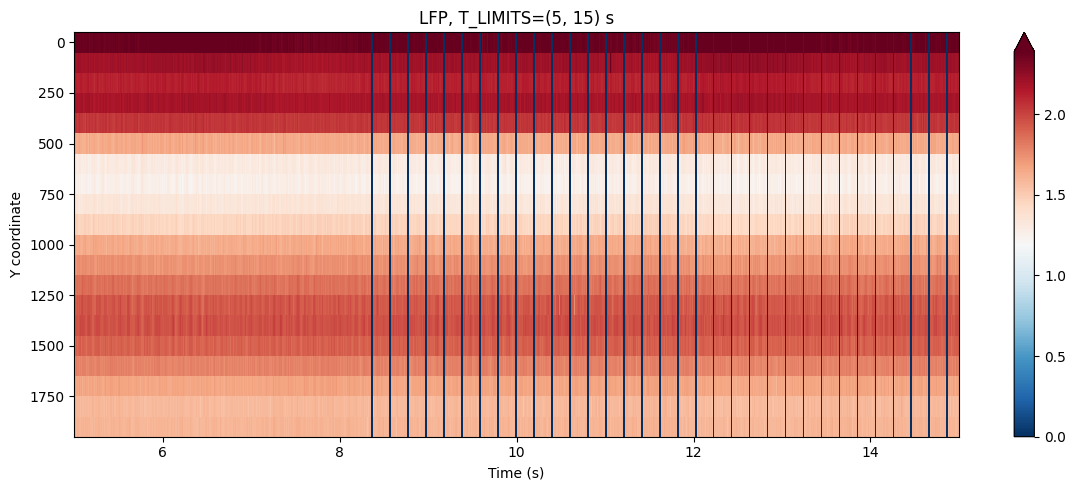

In [8]:
# Plot LFP
fig, ax = plt.subplots(figsize=(12, 5))
lfp_sel.plot(ax=ax, x='time', y='y', cmap='RdBu_r', robust=True)
ax.set_title(f'LFP, T_LIMITS={T_LIMITS} s')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Y coordinate')
ax.invert_yaxis()
plt.tight_layout()

In [ ]:
# Compute PSD for one LFP channel using Welch method
lfp_psd_in = lfp_sel.isel(y=PSD_CHAN_IDX)
psd = calc_xr_welch(
    lfp_psd_in,
    win_len=WIN_LEN,
    win_overlap=WIN_OVERLAP,
    fmax=FMAX,
    compute=True,
    store_proc_info=True,
)
print('PSD input y coordinate:', float(lfp_psd_in.coords['y'].item()))
psd

PSD input y coordinate: 0.0


<xarray.DataArray (freq: 101)> Size: 808B
array([7.80787088e-05, 2.15736832e-04, 4.11161506e-05, 2.18765591e-05,
       1.31434053e-05, 8.64123057e-06, 6.52085326e-06, 4.85818357e-06,
       4.72539896e-06, 5.40693803e-06, 7.16348185e-06, 1.02091461e-05,
       7.96423745e-06, 8.25919556e-06, 3.71339133e-06, 2.52434637e-06,
       1.59974226e-06, 1.18960470e-06, 1.58654396e-06, 9.86413056e-07,
       6.14233149e-07, 9.50929143e-07, 7.63876575e-07, 6.65482573e-07,
       5.80015480e-07, 7.24346981e-07, 5.79345082e-07, 6.63249222e-07,
       8.48382275e-07, 7.82798523e-07, 6.95234227e-07, 4.98093381e-07,
       8.56066575e-07, 8.58300265e-07, 5.78790832e-07, 4.19702056e-07,
       5.53517526e-07, 3.99365053e-07, 3.66068319e-07, 4.30929795e-07,
       4.12469315e-07, 4.82148844e-07, 5.94503425e-07, 3.75204996e-07,
       6.47589514e-07, 5.94433241e-07, 3.86235394e-07, 5.02930901e-07,
       4.88045358e-07, 4.54649849e-07, 3.91624019e-07, 5.29107191e-07,
       6.08218621e-07, 3.28930992e-07, 4.40228608e-07, 5.68074100e-07,
       4.80690400e-07, 3.69878616e-07, 2.65947204e-07, 2.83197222e-07,
       3.44751170e-07, 4.35259740e-07, 2.85796640e-07, 2.98540887e-07,
       3.94457475e-07, 4.78771908e-07, 4.77877413e-07, 5.10294833e-07,
       5.24833726e-07, 3.12129348e-07, 3.21937029e-07, 2.65350660e-07,
       2.30467196e-07, 2.81261663e-07, 4.46439906e-07, 4.84451861e-07,
       3.93192855e-07, 3.67950000e-07, 3.26725124e-07, 3.36483405e-07,
       3.79850611e-07, 3.60754817e-07, 3.35839816e-07, 2.93680718e-07,
       2.83075852e-07, 3.63353136e-07, 3.68737094e-07, 3.43185873e-07,
       2.54531942e-07, 2.31267252e-07, 3.07532122e-07, 2.72437692e-07,
       2.48188607e-07, 3.06323800e-07, 3.32752879e-07, 3.24323480e-07,
       2.60366164e-07, 2.87701422e-07, 2.97801440e-07, 3.26538703e-07,
       3.37697530e-07])
Coordinates:
    y        int64 8B 0
  * freq     (freq) float64 808B 0.0 1.0 2.0 3.0 4.0 ... 97.0 98.0 99.0 100.0
Attributes:
    proc_steps:  [{'name': 'calc_xr_welch', 'params': {'win_len': 1.0, 'win_o...

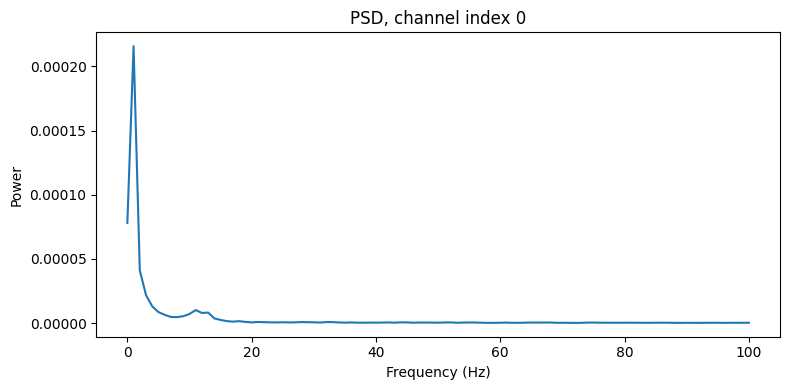

In [11]:
# Plot channel PSD
fig, ax = plt.subplots(figsize=(8, 4))
psd.plot(ax=ax)
ax.set_title(f'PSD, channel index {PSD_CHAN_IDX}')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power')
plt.tight_layout()

In [ ]:
# Select one LFP channel for 1D trace plotting
lfp_trace = lfp_sel.isel(y=LFP_TRACE_CHAN_IDX)
print('Trace input y coordinate:', float(lfp_trace.coords['y'].item()))
lfp_trace

# Plot one LFP channel as voltage vs. time
fig, ax = plt.subplots(figsize=(12, 4))
lfp_trace.plot(ax=ax)
ax.set_title(f'LFP trace, channel index {LFP_TRACE_CHAN_IDX}')
ax.set_xlabel('Time (s)')
ax.set_ylabel('LFP')
plt.tight_layout()

In [ ]:
# Compute time-frequency transform for one LFP channel
lfp_tf_in = lfp_sel.isel(y=TF_CHAN_IDX)
tf = calc_xr_tf(
    lfp_tf_in,
    win_len=WIN_LEN,
    win_overlap=WIN_OVERLAP,
    fmax=FMAX,
    compute=True,
    store_proc_info=True,
)
print('TF input y coordinate:', float(lfp_tf_in.coords['y'].item()))
tf

In [ ]:
# Plot time-frequency transform magnitude
fig, ax = plt.subplots(figsize=(12, 5))
abs(tf).plot(ax=ax, x='time', y='freq', robust=True)
ax.set_title(f'TF magnitude, channel index {TF_CHAN_IDX}')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
plt.tight_layout()

In [ ]:
lfp_cpsd_1 = lfp_sel.isel(y=CPSD_CHAN_IDXS[0])
lfp_cpsd_2 = lfp_sel.isel(y=CPSD_CHAN_IDXS[1])
cpsd = calc_xr_cpsd(
    lfp_cpsd_1,
    lfp_cpsd_2,
    win_len=WIN_LEN,
    win_overlap=WIN_OVERLAP,
    fmax=FMAX,
    compute=True,
    store_proc_info=True,
)
print('CPSD input y coordinates:', float(lfp_cpsd_1.coords['y'].item()), float(lfp_cpsd_2.coords['y'].item()))
print(cpsd)

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
abs(cpsd).plot(ax=axes[0])
axes[0].set_title(f'CPSD magnitude, channel indices {CPSD_CHAN_IDXS}')
axes[0].set_ylabel('|CPSD|')
phase = xr.apply_ufunc(np.angle, cpsd)
phase.plot(ax=axes[1])
axes[1].set_title('CPSD phase')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Phase (rad)')
plt.tight_layout()